# EXIOBASE3 hotspot analysis for Sweden with pymrio

This notebook loads the EXIOBASE3 monetary PxP IOT, calculates the missing MRIO tables with `pymrio`, and produces a Sweden-focused hotspot analysis for:

1. economic importance,
2. greenhouse-gas impacts,
3. material footprint,

for both consumption-based accounting (CBA) and production-based accounting (PBA). It also derives source-country shares for the hotspot sectors.

## Key assumptions used in this notebook

- **Economic importance** is represented by the `factor_inputs` extension row **`Value Added`**.
- **GHG impacts** are represented by the `impact` extension row **`global warming (GWP100)`** only when a characterized `impact` extension is actually available. If not, the notebook skips GHG with an explicit note rather than assuming a proxy.
- **Material footprint** is represented from the **`materials`** extension. The notebook first tries to find a single “total used-material” style row. If none is found, it sums eligible material rows after checking that the units are consistent.
- **Source-country shares for PBA sectors are trivial by definition**: for Swedish PBA hotspots, the source country is Sweden (`SE`) because PBA records impacts occurring in Swedish production sectors.
- The country-origin decomposition for **CBA** is implemented in a memory-conscious way from `S`, `L`, and Swedish final demand, rather than by fully diagonalizing a stressor, because that approach becomes very memory-intensive for full EXIOBASE systems.

## Before running

- Adjust the settings in the configuration cell if needed.
- Expect parsing and `calc_all()` on EXIOBASE to take noticeable time and memory.

In [1]:
# Optional: install missing packages from inside the notebook
# %pip install pymrio pandas numpy matplotlib openpyxl

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymrio

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# -----------------------------
# User configuration
# -----------------------------
DATA_PATH = Path(r"C:\EXIOBASE3\IOT_2022_pxp.zip")
TARGET_REGION = "SE"

TOP_N_SECTORS = 15          # ranking tables and charts
TOP_N_SOURCE_SECTORS = 5    # how many hotspot sectors per indicator/account to trace to source countries
TOP_N_SOURCE_COUNTRIES = 10 # number of source countries shown per hotspot sector

# Set this to a row label or list of row labels if you want to override
# the automatic material-footprint row selection.
# Examples:
# MATERIAL_ROW_SELECTION = "Total material extraction"
# MATERIAL_ROW_SELECTION = [("Used", "Biomass"), ("Used", "Metal ores")]
MATERIAL_ROW_SELECTION = None


# GHG proxy configuration used only when no characterized `impact` extension is present.
# Default factors follow the common AR5 100-year GWPs for CO2, CH4, and N2O.
GWP100_FACTORS = {
    "CO2": 1.0,
    "CH4": 28.0,
    "N2O": 265.0,
}

# Optional manual override for GHG rows when using the raw air-emissions extension.
# Example format:
# GHG_ROW_SELECTION = {
#     ("Carbon dioxide", "air"): 1.0,
#     ("Methane", "air"): 28.0,
#     ("Nitrous oxide", "air"): 265.0,
# }
GHG_ROW_SELECTION = None

OUTPUT_DIR = Path.cwd() / "exiobase3_sweden_hotspot_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:

from types import SimpleNamespace


def row_to_text(row_label):
    """Render row labels consistently for exact matching and reporting."""
    if isinstance(row_label, tuple):
        return " | ".join(str(x) for x in row_label)
    return str(row_label)


def as_listlike(row_selector):
    if isinstance(row_selector, (list, tuple, pd.Index, np.ndarray)):
        return row_selector
    return [row_selector]


def select_rows(df, row_selector):
    """
    Safe row selection for regular and MultiIndex row labels.
    Returns a DataFrame even for a single row.
    """
    if isinstance(row_selector, tuple) and not isinstance(df.index, pd.MultiIndex):
        return df.loc[[row_selector]]
    if isinstance(row_selector, (list, pd.Index, np.ndarray)):
        return df.loc[list(row_selector)]
    return df.loc[[row_selector]]


def sum_selected_rows(df, row_selector):
    selected = select_rows(df, row_selector)
    if selected.shape[0] == 1:
        return selected.iloc[0]
    return selected.sum(axis=0)


def aggregate_final_demand_by_region(Y):
    """
    Aggregate final demand categories to one column per region.
    """
    if isinstance(Y.columns, pd.MultiIndex):
        col_level = "region" if "region" in Y.columns.names else 0
        return Y.T.groupby(level=col_level, sort=False).sum().T
    return Y.copy()


def split_region_sector_columns(df, target_region):
    """
    Return the sector columns for a specific region from a standard pymrio account table.
    """
    if isinstance(df.columns, pd.MultiIndex):
        level = "region" if "region" in df.columns.names else 0
        return df.xs(target_region, axis=1, level=level)
    raise ValueError("Expected a pymrio-style DataFrame with MultiIndex columns (region, sector).")


def ranking_from_account(account_df, row_selector, target_region, account_name, indicator_name, unit=None):
    """
    Build a tidy ranking table for one indicator and one account type.
    """
    regional_df = split_region_sector_columns(account_df, target_region)
    values = sum_selected_rows(regional_df, row_selector).astype(float)
    values = values.sort_values(ascending=False)

    total = values.sum()
    out = (
        values.rename("value")
        .reset_index()
        .rename(columns={"index": "sector", "sector": "sector"})
    )
    if "sector" not in out.columns:
        out.columns = ["sector", "value"]

    out["account"] = account_name
    out["indicator"] = indicator_name
    out["region"] = target_region
    out["share_of_region_total"] = np.where(total != 0, out["value"] / total, np.nan)
    out["rank"] = np.arange(1, len(out) + 1)
    out["unit"] = unit
    return out[["account", "indicator", "region", "sector", "value", "share_of_region_total", "rank", "unit"]]


def _extract_units_from_selection(unit_obj, row_selector):
    if unit_obj is None:
        return []

    if isinstance(unit_obj, pd.DataFrame):
        selected = select_rows(unit_obj, row_selector)
        if selected.shape[1] == 1:
            units = selected.iloc[:, 0].astype(str).str.strip().dropna().unique().tolist()
        else:
            units = pd.unique(selected.astype(str).stack().str.strip()).tolist()
    elif isinstance(unit_obj, pd.Series):
        if isinstance(row_selector, (list, pd.Index, np.ndarray)):
            selected = unit_obj.loc[list(row_selector)]
        else:
            selected = unit_obj.loc[[row_selector]]
        units = selected.astype(str).str.strip().dropna().unique().tolist()
    else:
        return []

    return [u for u in units if u and u.lower() != "nan"]


def detect_common_unit(ext, row_selector):
    """
    Try to detect a common unit across selected extension rows.
    """
    try:
        units = _extract_units_from_selection(getattr(ext, "unit", None), row_selector)
        if len(units) == 1:
            return units[0]
        if len(units) == 0:
            return None
        raise ValueError(f"Selected rows do not have a single common unit: {units}")
    except Exception:
        return None


def get_extension_map(mrio):
    return {name: getattr(mrio, name) for name in mrio.get_extensions() if hasattr(mrio, name)}


def resolve_extension(mrio, exact=None, contains=None, row_contains=None, required=False, label="extension"):
    """
    Resolve an extension dynamically from the parsed MRIO object.
    """
    ext_map = get_extension_map(mrio)

    for candidate in (exact or []):
        if candidate in ext_map:
            return ext_map[candidate], candidate

    contains = [c.lower() for c in (contains or [])]
    if contains:
        for name, ext in ext_map.items():
            lname = name.lower()
            if any(c in lname for c in contains):
                return ext, name

    row_contains = [c.lower() for c in (row_contains or [])]
    if row_contains:
        for name, ext in ext_map.items():
            try:
                rows = [row_to_text(r).lower() for r in list(ext.get_rows())[:500]]
            except Exception:
                continue
            if any(any(token in txt for token in row_contains) for txt in rows):
                return ext, name

    if required:
        raise KeyError(
            f"Could not resolve {label}. Available extensions: {list(ext_map.keys())}"
        )
    return None, None


def preview_extension_rows(ext, n=50):
    try:
        return [row_to_text(x) for x in list(ext.get_rows())[:n]]
    except Exception:
        return []


def choose_first_matching_row(ext, exact=None, contains=None):
    """
    Return the first matching extension row using exact and substring matching.
    """
    rows = list(ext.get_rows())
    row_map = {row_to_text(r).strip().lower(): r for r in rows}

    for candidate in (exact or []):
        key = str(candidate).strip().lower()
        if key in row_map:
            return row_map[key]

    for needle in (contains or []):
        needle = str(needle).strip().lower()
        for r in rows:
            txt = row_to_text(r).strip().lower()
            if needle in txt:
                return r

    available_preview = [row_to_text(r) for r in rows[:30]]
    raise KeyError(
        "Could not find a matching row. "
        f"Exact candidates={exact}, contains candidates={contains}. "
        f"First available rows: {available_preview}"
    )


def choose_material_rows(materials_ext, override=None):
    """
    Heuristic material-row selector.

    Strategy:
    1. Use explicit override if provided.
    2. Prefer a single row that looks like a total used-material row.
    3. Otherwise sum rows that look like 'used' material rows and exclude 'unused'.
    4. As last resort, sum all rows only if units are consistent.
    """
    if override is not None:
        return override, "User-specified material row selection"

    rows = list(materials_ext.get_rows())
    row_text = pd.Series({row: row_to_text(row).lower() for row in rows})

    preferred_rows = []
    for row, txt in row_text.items():
        if (
            ("total" in txt or "all" in txt)
            and ("material" in txt or "domestic extraction" in txt or "used" in txt)
            and "unused" not in txt
        ):
            preferred_rows.append(row)

    if len(preferred_rows) == 1:
        return preferred_rows[0], f"Automatically selected material row: {row_to_text(preferred_rows[0])}"

    used_rows = []
    for row, txt in row_text.items():
        if "unused" in txt:
            continue
        if any(
            k in txt
            for k in [
                "used",
                "material",
                "domestic extraction",
                "biomass",
                "metal ores",
                "non-metallic minerals",
                "fossil",
            ]
        ):
            used_rows.append(row)

    if len(used_rows) > 0:
        return used_rows, "Automatically selected and summed multiple material rows"

    unit = detect_common_unit(materials_ext, rows)
    if unit is not None:
        return rows, "No clear material-total row found; summing all material rows because units appear consistent"

    raise ValueError(
        "Could not determine a safe material-footprint row selection automatically. "
        "Inspect the material extension rows and set MATERIAL_ROW_SELECTION explicitly."
    )


def find_rows_containing(ext, include_any, exclude_any=None):
    matches = []
    include_any = [s.lower() for s in (include_any or [])]
    exclude_any = [s.lower() for s in (exclude_any or [])]
    for row in list(ext.get_rows()):
        txt = row_to_text(row).lower()
        if include_any and not any(token in txt for token in include_any):
            continue
        if exclude_any and any(token in txt for token in exclude_any):
            continue
        matches.append(row)
    return matches


def choose_ghg_row_factors(emissions_ext, override=None, default_factors=None):
    """
    Build a row->GWP factor mapping from a raw air-emissions extension.

    Default behavior is a transparent CO2+CH4+N2O proxy when no characterized impact
    extension is available.
    """
    if override is not None:
        return override, "User-specified GHG row selection"

    default_factors = default_factors or {"CO2": 1.0, "CH4": 28.0, "N2O": 265.0}
    row_factor_map = {}
    notes = []

    gas_patterns = {
        "CO2": ["carbon dioxide", "co2"],
        "CH4": ["methane", "ch4"],
        "N2O": ["nitrous oxide", "n2o"],
    }

    gas_excludes = {
        "CO2": ["co2-equivalent", "co2 equivalent", "gwp"],
        "CH4": [],
        "N2O": ["nitrogen oxides", "nox"],
    }

    for gas, patterns in gas_patterns.items():
        rows = find_rows_containing(emissions_ext, include_any=patterns, exclude_any=gas_excludes.get(gas))
        if rows:
            for row in rows:
                row_factor_map[row] = default_factors[gas]
            notes.append(f"{gas}: {len(rows)} row(s)")
        else:
            notes.append(f"{gas}: no row found")

    if not row_factor_map:
        preview = preview_extension_rows(emissions_ext, n=80)
        raise ValueError(
            "Could not identify any CO2/CH4/N2O rows in the emissions extension. "
            f"First rows: {preview}"
        )

    return row_factor_map, "Automatically built raw-emissions GHG proxy using " + ", ".join(notes)


def characterize_account_from_row_factors(account_df, row_factor_map, row_name):
    pieces = []
    for row, factor in row_factor_map.items():
        piece = select_rows(account_df, row).astype(float) * float(factor)
        pieces.append(piece)
    combined = pd.concat(pieces, axis=0).groupby(level=0).sum() if len(pieces) > 1 else pieces[0]
    if isinstance(combined, pd.DataFrame) and combined.shape[0] > 1:
        combined = combined.sum(axis=0)
    elif isinstance(combined, pd.DataFrame) and combined.shape[0] == 1:
        combined = combined.iloc[0]
    return pd.DataFrame([combined], index=pd.Index([row_name], name="impact"))


def build_characterized_proxy_extension(ext, row_factor_map, row_name="GHG proxy", impact_unit="kg CO2-eq"):
    proxy = SimpleNamespace()
    proxy.name = row_name
    proxy.S = characterize_account_from_row_factors(ext.S, row_factor_map, row_name)
    proxy.D_cba = characterize_account_from_row_factors(ext.D_cba, row_factor_map, row_name)
    proxy.D_pba = characterize_account_from_row_factors(ext.D_pba, row_factor_map, row_name)
    proxy.unit = pd.DataFrame({"unit": [impact_unit]}, index=pd.Index([row_name], name="impact"))
    return proxy


def cba_source_country_shares(mrio, ext, row_selector, target_region, target_sector, Y_agg, top_n=10):
    """
    Attribute the CBA of one (target_region, target_sector) final-demand column to source countries.

    Calculation:
    contribution_by_source_sector = selected_S @ L @ y_target_sector
    then aggregate by source country.
    """
    if not isinstance(mrio.L.columns, pd.MultiIndex):
        raise ValueError("Expected mrio.L columns to be a MultiIndex with region and sector.")

    if isinstance(Y_agg.columns, pd.MultiIndex):
        raise ValueError("Y_agg should already be aggregated to one column per region.")

    y_target = Y_agg.loc[:, target_region].copy()

    if isinstance(y_target.index, pd.MultiIndex):
        y_target.loc[:] = 0.0
        y_target.loc[(target_region, target_sector)] = Y_agg.loc[(target_region, target_sector), target_region]
    else:
        raise ValueError("Expected Y_agg rows to be MultiIndex (region, sector).")

    selected_S = sum_selected_rows(ext.S, row_selector).astype(float)

    source_vector = selected_S @ mrio.L @ y_target
    source_vector = pd.Series(source_vector, index=mrio.L.columns, name="source_value")

    country_shares = source_vector.groupby(level="region").sum().sort_values(ascending=False)
    total = country_shares.sum()

    out = country_shares.reset_index()
    out.columns = ["source_country", "source_value"]
    out["source_share"] = np.where(total != 0, out["source_value"] / total, np.nan)
    out["target_region"] = target_region
    out["target_sector"] = target_sector
    out = out[["target_region", "target_sector", "source_country", "source_value", "source_share"]]

    if top_n is not None:
        out = out.head(top_n).reset_index(drop=True)

    return out


def pba_source_country_shares(target_region, target_sector, value):
    """
    For PBA of a Swedish sector, the source country is Sweden by definition.
    """
    return pd.DataFrame(
        {
            "target_region": [target_region],
            "target_sector": [target_sector],
            "source_country": [target_region],
            "source_value": [value],
            "source_share": [1.0],
        }
    )


def plot_top_sectors(df, title, top_n=15):
    """
    Simple horizontal bar chart for the top sectors.
    """
    plot_df = df.head(top_n).sort_values("value", ascending=True)

    plt.figure(figsize=(10, max(5, 0.35 * len(plot_df))))
    plt.barh(plot_df["sector"], plot_df["value"])
    plt.title(title)
    plt.xlabel(plot_df["unit"].dropna().iloc[0] if "unit" in plot_df.columns and plot_df["unit"].notna().any() else "value")
    plt.tight_layout()
    plt.show()


In [4]:
# Check that the file exists before starting heavy calculations
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find EXIOBASE at: {DATA_PATH}\n"
        "Update DATA_PATH in the configuration cell to match your local file."
    )

print(f"Loading EXIOBASE from: {DATA_PATH}")
mrio = pymrio.parse_exiobase3(DATA_PATH)

print("Calculating missing MRIO tables and accounts. This can take substantial time and memory.")
mrio.calc_all()

print("Loaded regions:", len(mrio.get_regions()))
print("Loaded sectors:", len(mrio.get_sectors()))
print("Extensions:", list(mrio.get_extensions()))

Loading EXIOBASE from: C:\EXIOBASE3\IOT_2022_pxp.zip
Calculating missing MRIO tables and accounts. This can take substantial time and memory.
Loaded regions: 49
Loaded sectors: 200
Extensions: ['impacts', 'satellite']


In [5]:

# Basic checks and dynamic extension inspection
assert TARGET_REGION in mrio.get_regions(), f"{TARGET_REGION} is not a valid EXIOBASE region code."

ext_map = get_extension_map(mrio)
print("Available extensions:")
display(pd.DataFrame({"extension": list(ext_map.keys())}))

factor_inputs_ext, factor_inputs_name = resolve_extension(
    mrio,
    exact=["factor_inputs", "factor_input"],
    contains=["factor_input"],
    row_contains=["value added"],
    required=True,
    label="factor-input extension",
)

materials_ext, materials_name = resolve_extension(
    mrio,
    exact=["materials", "material"],
    contains=["material", "resource"],
    row_contains=["biomass", "metal ores", "non-metallic minerals", "domestic extraction", "material"],
    required=False,
    label="material extension",
)

impact_ext, impact_name = resolve_extension(
    mrio,
    exact=["impact", "impacts"],
    contains=["impact"],
    row_contains=["global warming", "gwp100"],
    required=False,
    label="impact extension",
)

emissions_ext, emissions_name = resolve_extension(
    mrio,
    exact=["air_emissions", "emissions", "satellite"],
    contains=["air_emission", "emission", "satellite"],
    row_contains=["carbon dioxide", "methane", "nitrous oxide", "co2", "ch4", "n2o"],
    required=False,
    label="emissions extension",
)

print(f"Resolved factor-input extension: {factor_inputs_name}")
if materials_ext is not None:
    print(f"Resolved material extension: {materials_name}")
else:
    print("Could not resolve a dedicated material extension automatically.")

if impact_ext is not None:
    print(f"Resolved impact extension: {impact_name}")
else:
    print("No characterized impact extension found.")

if emissions_ext is not None:
    print(f"Resolved emissions extension: {emissions_name}")
else:
    print("No raw emissions extension found.")

print("Factor input rows (first 30):")
display(pd.DataFrame({"factor_input_row": preview_extension_rows(factor_inputs_ext, 30)}))

if materials_ext is not None:
    print("Material extension rows (first 50):")
    display(pd.DataFrame({"material_row": preview_extension_rows(materials_ext, 50)}))

if impact_ext is not None:
    print("Impact rows (first 30):")
    display(pd.DataFrame({"impact_row": preview_extension_rows(impact_ext, 30)}))

if emissions_ext is not None:
    print("Emissions rows (first 50):")
    display(pd.DataFrame({"emission_row": preview_extension_rows(emissions_ext, 50)}))


Available extensions:


,extension
0,impacts
1,satellite


Resolved factor-input extension: impacts
Resolved material extension: impacts
Resolved impact extension: impacts
Resolved emissions extension: satellite
Factor input rows (first 30):


,factor_input_row
0,Value Added
1,Employment
2,Employment hour
3,GHG emissions (GWP100) | Problem oriented appr...
4,Human toxicity (USEtox) | USEtox2008 | CTUh (R...
5,Fresh water Ecotoxicity (USEtox) | USEtox2008 ...
6,"EPS | Damage Approach | EPS (Steen, 1999))"
7,Carcinogenic effects on humans (H.A) | ECOINDI...
8,Respiratory effects on humans caused by organi...
9,Respiratory effects on humans caused by inorga...


Material extension rows (first 50):


,material_row
0,Value Added
1,Employment
2,Employment hour
3,GHG emissions (GWP100) | Problem oriented appr...
4,Human toxicity (USEtox) | USEtox2008 | CTUh (R...
5,Fresh water Ecotoxicity (USEtox) | USEtox2008 ...
6,"EPS | Damage Approach | EPS (Steen, 1999))"
7,Carcinogenic effects on humans (H.A) | ECOINDI...
8,Respiratory effects on humans caused by organi...
9,Respiratory effects on humans caused by inorga...


Impact rows (first 30):


,impact_row
0,Value Added
1,Employment
2,Employment hour
3,GHG emissions (GWP100) | Problem oriented appr...
4,Human toxicity (USEtox) | USEtox2008 | CTUh (R...
5,Fresh water Ecotoxicity (USEtox) | USEtox2008 ...
6,"EPS | Damage Approach | EPS (Steen, 1999))"
7,Carcinogenic effects on humans (H.A) | ECOINDI...
8,Respiratory effects on humans caused by organi...
9,Respiratory effects on humans caused by inorga...


Emissions rows (first 50):


,emission_row
0,Taxes less subsidies on products purchased: Total
1,Other net taxes on production
2,"Compensation of employees; wages, salaries, & ..."
3,"Compensation of employees; wages, salaries, & ..."
4,"Compensation of employees; wages, salaries, & ..."
5,Operating surplus: Consumption of fixed capital
6,Operating surplus: Rents on land
7,Operating surplus: Royalties on resources
8,Operating surplus: Remaining net operating sur...
9,Employment: Low-skilled male


In [6]:
# Prepare the final-demand aggregation used by pymrio account calculations
Y_agg = aggregate_final_demand_by_region(mrio.Y)

print("Y aggregated to one column per region:")
display(Y_agg.iloc[:5, :5])

print("Selected region:", TARGET_REGION)

Y aggregated to one column per region:


region                                  AT        BE        BG   CY        CZ
region sector                                                                
AT     Paddy rice                 0.000000  0.000000  0.000000  0.0  0.000000
       Wheat                     15.927368  0.469751  0.017716  0.0  0.165116
       Cereal grains nec        158.736623  0.011550  0.067395  0.0  1.300266
       Vegetables, fruit, nuts  852.025868  0.545598  0.510609  0.0  9.114596
       Oil seeds                  0.000000  0.145227  0.004715  0.0  0.889365

Selected region: SE


In [7]:

# Indicator definitions
# Uses the dynamically resolved extensions from the inspection cell above.

value_added_row = choose_first_matching_row(
    factor_inputs_ext,
    exact=["Value Added"],
    contains=["value added"],
)

indicator_specs = {
    "economic_importance": {
        "extension": factor_inputs_ext,
        "row_selector": value_added_row,
        "unit": detect_common_unit(factor_inputs_ext, value_added_row),
        "label": "Value added",
    }
}

material_note = None
if materials_ext is not None:
    material_rows, material_note = choose_material_rows(materials_ext, override=MATERIAL_ROW_SELECTION)
    indicator_specs["materials"] = {
        "extension": materials_ext,
        "row_selector": material_rows,
        "unit": detect_common_unit(materials_ext, material_rows),
        "label": "Material footprint",
    }
else:
    material_note = (
        "No dedicated material extension was resolved automatically. "
        "The notebook will continue without a material footprint result unless you manually map the right extension."
    )

ghg_note = None
ghg_row_selector = None
ghg_extension = None

if impact_ext is not None:
    ghg_row = choose_first_matching_row(
        impact_ext,
        exact=["global warming (GWP100)"],
        contains=["global warming (gwp100)", "global warming", "gwp100"],
    )
    ghg_extension = impact_ext
    ghg_row_selector = ghg_row
    ghg_note = f"Using characterized GHG impacts from `{impact_name}`."
else:
    if emissions_ext is not None:
        ghg_row_factors, ghg_note_detail = choose_ghg_row_factors(
            emissions_ext,
            override=GHG_ROW_SELECTION,
            default_factors=GWP100_FACTORS,
        )
        base_mass_unit = detect_common_unit(emissions_ext, list(ghg_row_factors.keys())) or "mass unit"
        ghg_label = "GHG proxy (CO2+CH4+N2O, GWP100)"
        ghg_extension = build_characterized_proxy_extension(
            emissions_ext,
            row_factor_map=ghg_row_factors,
            row_name=ghg_label,
            impact_unit=f"{base_mass_unit} CO2-eq" if "CO2-eq" not in str(base_mass_unit) else str(base_mass_unit),
        )
        ghg_row_selector = ghg_label
        ghg_note = (
            "No characterized impact extension was found, so the notebook built a transparent GHG proxy "
            f"from raw emissions using the configured GWP100 factors. {ghg_note_detail}"
        )
    else:
        ghg_note = (
            "Neither a characterized impact extension nor a raw emissions extension was found. "
            "GHG hotspot results are skipped."
        )

if ghg_extension is not None:
    indicator_specs["ghg"] = {
        "extension": ghg_extension,
        "row_selector": ghg_row_selector,
        "unit": detect_common_unit(ghg_extension, ghg_row_selector),
        "label": "GHG impacts" if impact_ext is not None else "GHG proxy (CO2+CH4+N2O)",
    }

print(f"Value added row: {row_to_text(value_added_row)}")
print(material_note)
print(ghg_note)

if "materials" in indicator_specs:
    material_rows = indicator_specs["materials"]["row_selector"]
    print("Material row selection:")
    if isinstance(material_rows, (list, pd.Index, np.ndarray)):
        display(pd.DataFrame({"selected_material_rows": [row_to_text(x) for x in material_rows]}))
    else:
        display(pd.DataFrame({"selected_material_rows": [row_to_text(material_rows)]}))

if ghg_extension is not None and impact_ext is None:
    print("GHG proxy row selection and factors:")
    display(
        pd.DataFrame(
            {
                "row": [row_to_text(r) for r in ghg_row_factors.keys()],
                "factor": list(ghg_row_factors.values()),
            }
        )
    )


Value added row: Value Added
Automatically selected and summed multiple material rows
Using characterized GHG impacts from `impacts`.
Material row selection:


,selected_material_rows
0,Respiratory effects on humans caused by organi...
1,Respiratory effects on humans caused by inorga...
2,Damages to human health caused by climate chan...
3,Damage to Ecosystem Quality caused by ecotoxic...
4,Damage to Ecosystem Quality caused by the comb...
5,Respiratory effects on humans caused by organi...
6,Respiratory effects on humans caused by inorga...
7,Damages to human health caused by climate chan...
8,Damage to Ecosystem Quality caused by ecotoxic...
9,Damage to Ecosystem Quality caused by the comb...


In [8]:
# Build Sweden hotspot rankings for CBA and PBA
ranking_tables = []

for indicator_name, spec in indicator_specs.items():
    ext = spec["extension"]
    row_selector = spec["row_selector"]
    unit = spec["unit"]

    ranking_tables.append(
        ranking_from_account(
            ext.D_cba,
            row_selector=row_selector,
            target_region=TARGET_REGION,
            account_name="CBA",
            indicator_name=indicator_name,
            unit=unit,
        )
    )

    ranking_tables.append(
        ranking_from_account(
            ext.D_pba,
            row_selector=row_selector,
            target_region=TARGET_REGION,
            account_name="PBA",
            indicator_name=indicator_name,
            unit=unit,
        )
    )

rankings = pd.concat(ranking_tables, ignore_index=True)
rankings.to_csv(OUTPUT_DIR / "sweden_sector_rankings_tidy.csv", index=False)

display(rankings.head(20))
print(f"Saved: {OUTPUT_DIR / 'sweden_sector_rankings_tidy.csv'}")

,account,indicator,region,sector,value,share_of_region_total,rank,unit
0,CBA,economic_importance,SE,Health and social work services (85),60441.090481,0.124688,1,M.EUR
1,CBA,economic_importance,SE,Construction work (45),57700.665862,0.119035,2,M.EUR
2,CBA,economic_importance,SE,Real estate services (70),45701.911287,0.094282,3,M.EUR
3,CBA,economic_importance,SE,Education services (80),31241.356604,0.064450,4,M.EUR
4,CBA,economic_importance,SE,Computer and related services (72),25365.892780,0.052329,5,M.EUR
5,CBA,economic_importance,SE,Public administration and defence services; co...,22909.817870,0.047262,6,M.EUR
6,CBA,economic_importance,SE,Membership organisation services n.e.c. (91),20456.758077,0.042202,7,M.EUR
7,CBA,economic_importance,SE,Supporting and auxiliary transport services; t...,20138.603057,0.041545,8,M.EUR
8,CBA,economic_importance,SE,Hotel and restaurant services (55),16414.736725,0.033863,9,M.EUR
9,CBA,economic_importance,SE,Post and telecommunication services (64),13404.081885,0.027652,10,M.EUR


Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_sector_rankings_tidy.csv


,account,indicator,region,sector,value,share_of_region_total,rank,unit
0,CBA,economic_importance,SE,Health and social work services (85),60441.090481,0.124688,1,M.EUR
1,CBA,economic_importance,SE,Construction work (45),57700.665862,0.119035,2,M.EUR
2,CBA,economic_importance,SE,Real estate services (70),45701.911287,0.094282,3,M.EUR
3,CBA,economic_importance,SE,Education services (80),31241.356604,0.064450,4,M.EUR
4,CBA,economic_importance,SE,Computer and related services (72),25365.892780,0.052329,5,M.EUR
5,CBA,economic_importance,SE,Public administration and defence services; co...,22909.817870,0.047262,6,M.EUR
6,CBA,economic_importance,SE,Membership organisation services n.e.c. (91),20456.758077,0.042202,7,M.EUR
7,CBA,economic_importance,SE,Supporting and auxiliary transport services; t...,20138.603057,0.041545,8,M.EUR
8,CBA,economic_importance,SE,Hotel and restaurant services (55),16414.736725,0.033863,9,M.EUR
9,CBA,economic_importance,SE,Post and telecommunication services (64),13404.081885,0.027652,10,M.EUR


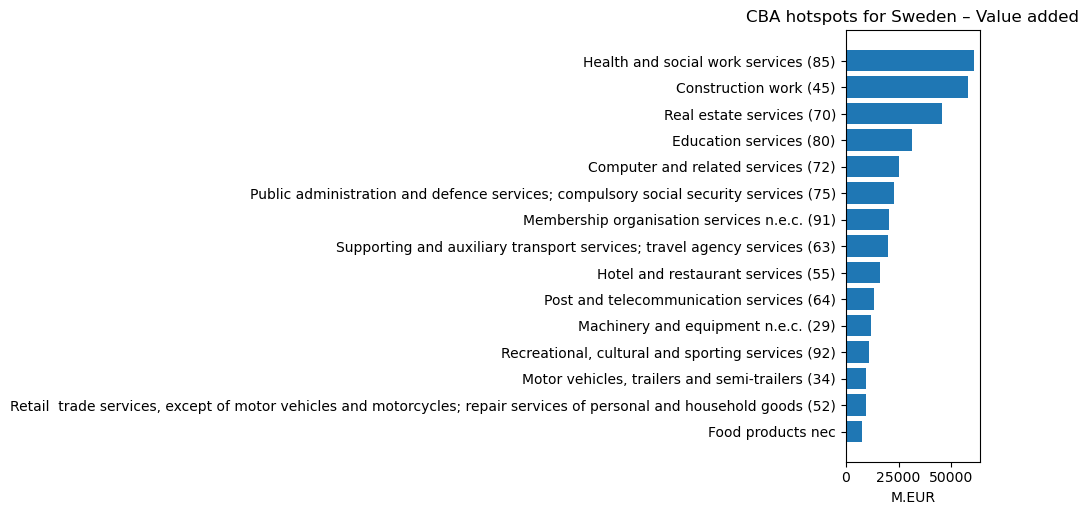

,account,indicator,region,sector,value,share_of_region_total,rank,unit
0,CBA,materials,SE,Construction work (45),5.722211e+09,0.116926,1,None
1,CBA,materials,SE,Machinery and equipment n.e.c. (29),5.302359e+09,0.108347,2,None
2,CBA,materials,SE,"Motor vehicles, trailers and semi-trailers (34)",3.980707e+09,0.081340,3,None
3,CBA,materials,SE,Real estate services (70),3.205187e+09,0.065494,4,None
4,CBA,materials,SE,"Fabricated metal products, except machinery an...",3.035187e+09,0.062020,5,None
5,CBA,materials,SE,Supporting and auxiliary transport services; t...,2.817159e+09,0.057565,6,None
6,CBA,materials,SE,Food products nec,1.991407e+09,0.040692,7,None
7,CBA,materials,SE,Electrical machinery and apparatus n.e.c. (31),1.502653e+09,0.030705,8,None
8,CBA,materials,SE,Products of meat cattle,1.427607e+09,0.029171,9,None
9,CBA,materials,SE,Hotel and restaurant services (55),1.425701e+09,0.029132,10,None


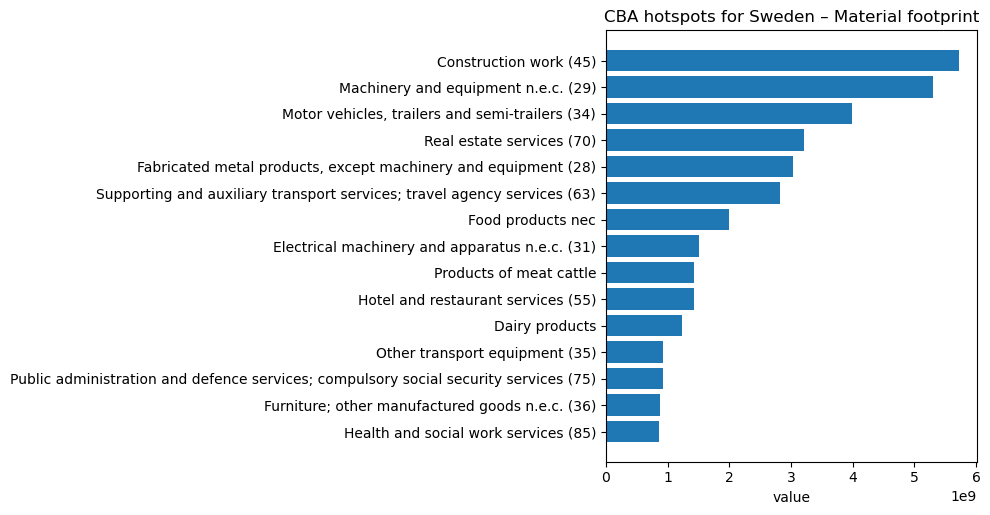

,account,indicator,region,sector,value,share_of_region_total,rank,unit
0,CBA,ghg,SE,Construction work (45),1.083442e+10,0.120396,1,kg CO2-Equivalents
1,CBA,ghg,SE,Real estate services (70),7.812965e+09,0.086820,2,kg CO2-Equivalents
2,CBA,ghg,SE,Steam and hot water supply services,4.360999e+09,0.048461,3,kg CO2-Equivalents
3,CBA,ghg,SE,Machinery and equipment n.e.c. (29),4.178178e+09,0.046429,4,kg CO2-Equivalents
4,CBA,ghg,SE,Supporting and auxiliary transport services; t...,4.146253e+09,0.046075,5,kg CO2-Equivalents
5,CBA,ghg,SE,Food products nec,4.142379e+09,0.046031,6,kg CO2-Equivalents
6,CBA,ghg,SE,Hotel and restaurant services (55),4.042973e+09,0.044927,7,kg CO2-Equivalents
7,CBA,ghg,SE,"Motor vehicles, trailers and semi-trailers (34)",3.197847e+09,0.035536,8,kg CO2-Equivalents
8,CBA,ghg,SE,Dairy products,3.161595e+09,0.035133,9,kg CO2-Equivalents
9,CBA,ghg,SE,Air transport services (62),2.721672e+09,0.030244,10,kg CO2-Equivalents


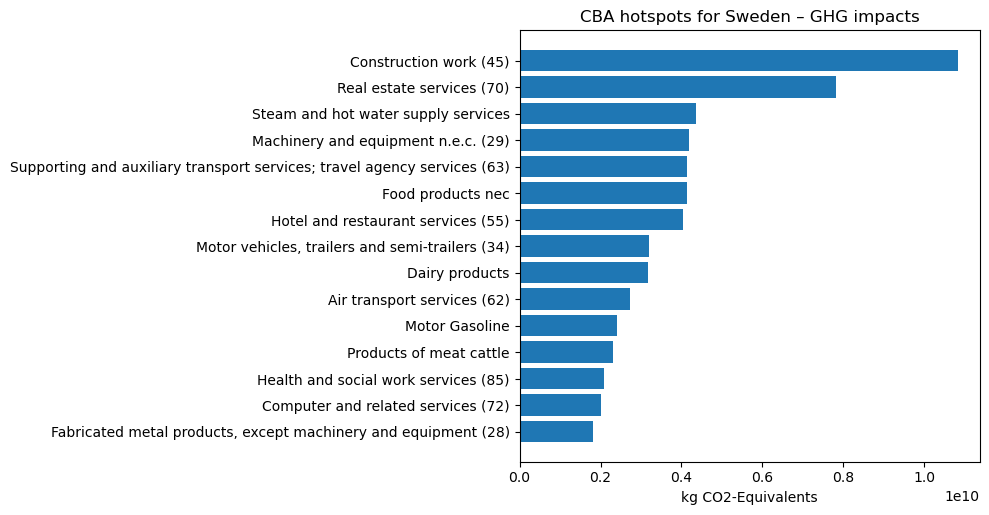

,account,indicator,region,sector,value,share_of_region_total,rank,unit
0,PBA,economic_importance,SE,Health and social work services (85),53334.147825,0.106517,1,M.EUR
1,PBA,economic_importance,SE,Other business services (74),47257.832623,0.094382,2,M.EUR
2,PBA,economic_importance,SE,Construction work (45),34933.695865,0.069768,3,M.EUR
3,PBA,economic_importance,SE,Education services (80),26784.143644,0.053492,4,M.EUR
4,PBA,economic_importance,SE,Computer and related services (72),26654.255565,0.053233,5,M.EUR
5,PBA,economic_importance,SE,Other land transportation services,20523.252840,0.040988,6,M.EUR
6,PBA,economic_importance,SE,"Wholesale trade and commission trade services,...",19804.533344,0.039553,7,M.EUR
7,PBA,economic_importance,SE,Supporting and auxiliary transport services; t...,18938.584863,0.037824,8,M.EUR
8,PBA,economic_importance,SE,Public administration and defence services; co...,18579.775956,0.037107,9,M.EUR
9,PBA,economic_importance,SE,Membership organisation services n.e.c. (91),16987.276044,0.033926,10,M.EUR


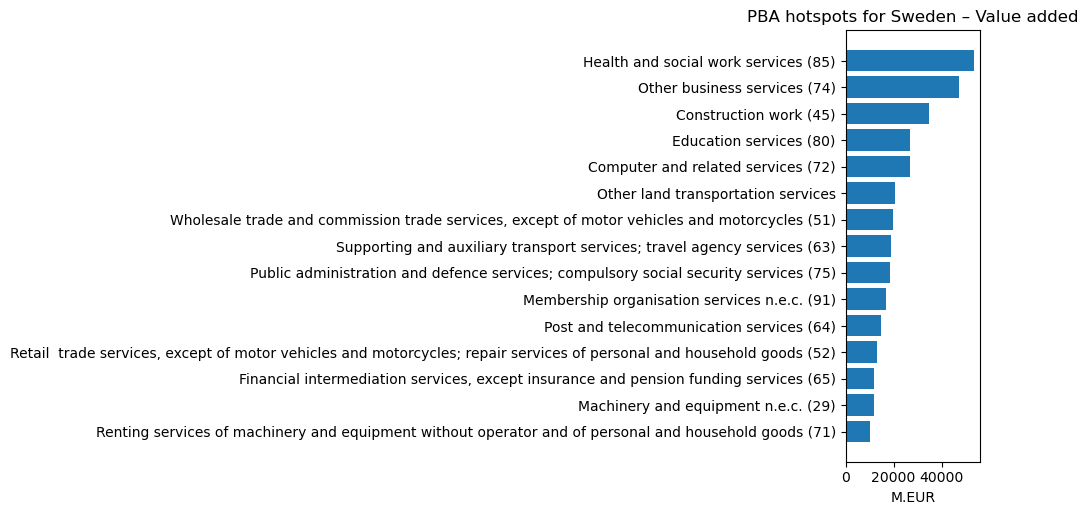

,account,indicator,region,sector,value,share_of_region_total,rank,unit
0,PBA,materials,SE,Basic iron and steel and of ferro-alloys and f...,6.791298e+09,0.360406,1,None
1,PBA,materials,SE,Sea and coastal water transportation services,3.420364e+09,0.181515,2,None
2,PBA,materials,SE,Cattle,1.028189e+09,0.054565,3,None
3,PBA,materials,SE,Raw milk,8.421251e+08,0.044691,4,None
4,PBA,materials,SE,Other business services (74),7.053637e+08,0.037433,5,None
5,PBA,materials,SE,Poultry,4.367015e+08,0.023175,6,None
6,PBA,materials,SE,Steam and hot water supply services,4.033312e+08,0.021404,7,None
7,PBA,materials,SE,Pigs,3.028599e+08,0.016072,8,None
8,PBA,materials,SE,Meat animals nec,3.022008e+08,0.016037,9,None
9,PBA,materials,SE,Cereal grains nec,2.871933e+08,0.015241,10,None


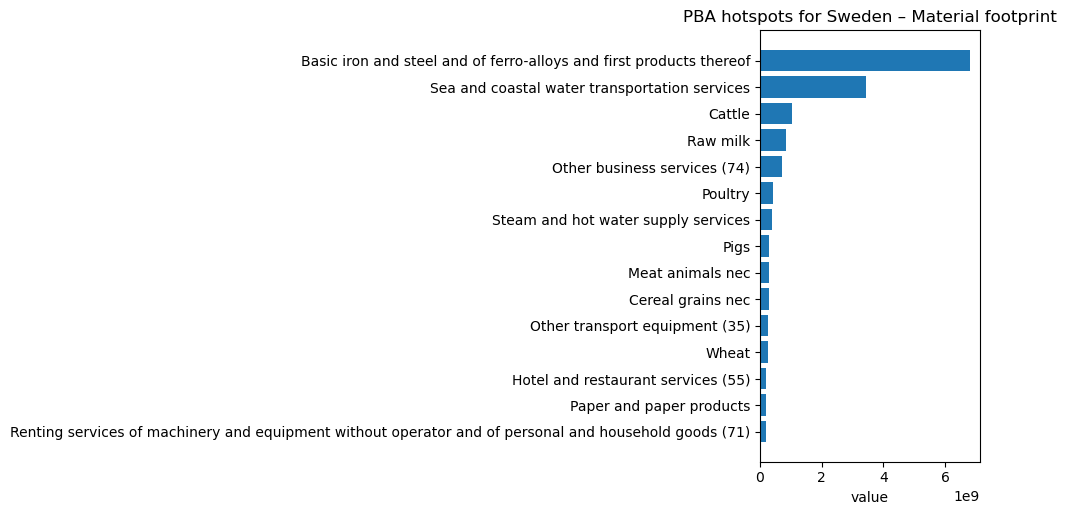

,account,indicator,region,sector,value,share_of_region_total,rank,unit
0,PBA,ghg,SE,Steam and hot water supply services,5.535877e+09,0.107613,1,kg CO2-Equivalents
1,PBA,ghg,SE,Food waste for treatment: landfill,3.781346e+09,0.073506,2,kg CO2-Equivalents
2,PBA,ghg,SE,Paper for treatment: landfill,2.890669e+09,0.056192,3,kg CO2-Equivalents
3,PBA,ghg,SE,Sea and coastal water transportation services,2.850032e+09,0.055402,4,kg CO2-Equivalents
4,PBA,ghg,SE,Basic iron and steel and of ferro-alloys and f...,2.400099e+09,0.046656,5,kg CO2-Equivalents
5,PBA,ghg,SE,Raw milk,2.250942e+09,0.043756,6,kg CO2-Equivalents
6,PBA,ghg,SE,Cattle,2.229208e+09,0.043334,7,kg CO2-Equivalents
7,PBA,ghg,SE,"Cement, lime and plaster",2.139059e+09,0.041581,8,kg CO2-Equivalents
8,PBA,ghg,SE,Other transport equipment (35),2.121716e+09,0.041244,9,kg CO2-Equivalents
9,PBA,ghg,SE,Air transport services (62),1.496762e+09,0.029096,10,kg CO2-Equivalents


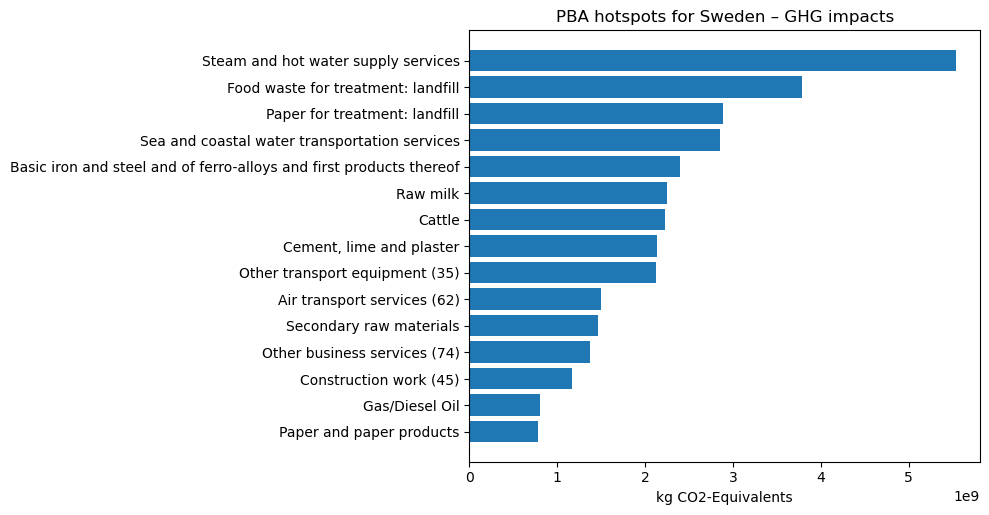

In [9]:
# Display top sectors by indicator and accounting principle
for account_name in ["CBA", "PBA"]:
    for indicator_name, spec in indicator_specs.items():
        title = f"{account_name} hotspots for Sweden – {spec['label']}"
        subset = (
            rankings
            .query("account == @account_name and indicator == @indicator_name")
            .sort_values("rank")
            .head(TOP_N_SECTORS)
            .reset_index(drop=True)
        )
        display(subset)
        plot_top_sectors(subset, title=title, top_n=TOP_N_SECTORS)

In [10]:
# Build source-country shares for top hotspot sectors
source_tables = []

for account_name in ["CBA", "PBA"]:
    for indicator_name, spec in indicator_specs.items():
        ext = spec["extension"]
        row_selector = spec["row_selector"]
        unit = spec["unit"]

        hotspot_subset = (
            rankings
            .query("account == @account_name and indicator == @indicator_name")
            .sort_values("rank")
            .head(TOP_N_SOURCE_SECTORS)
            .copy()
        )

        for _, row in hotspot_subset.iterrows():
            sector = row["sector"]
            sector_value = row["value"]

            if account_name == "CBA":
                src = cba_source_country_shares(
                    mrio=mrio,
                    ext=ext,
                    row_selector=row_selector,
                    target_region=TARGET_REGION,
                    target_sector=sector,
                    Y_agg=Y_agg,
                    top_n=TOP_N_SOURCE_COUNTRIES,
                )
            else:
                src = pba_source_country_shares(
                    target_region=TARGET_REGION,
                    target_sector=sector,
                    value=sector_value,
                )

            src["account"] = account_name
            src["indicator"] = indicator_name
            src["target_sector_value"] = sector_value
            src["unit"] = unit
            source_tables.append(src)

source_country_shares = pd.concat(source_tables, ignore_index=True)
source_country_shares.to_csv(OUTPUT_DIR / "sweden_source_country_shares.csv", index=False)

display(source_country_shares.head(30))
print(f"Saved: {OUTPUT_DIR / 'sweden_source_country_shares.csv'}")

,target_region,target_sector,source_country,source_value,source_share,account,indicator,target_sector_value,unit
0,SE,Health and social work services (85),AT,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
1,SE,Health and social work services (85),AU,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
2,SE,Health and social work services (85),BE,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
3,SE,Health and social work services (85),BG,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
4,SE,Health and social work services (85),BR,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
5,SE,Health and social work services (85),CA,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
6,SE,Health and social work services (85),CH,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
7,SE,Health and social work services (85),CN,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
8,SE,Health and social work services (85),CY,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR
9,SE,Health and social work services (85),CZ,1.195106e+07,0.020408,CBA,economic_importance,60441.090481,M.EUR


Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_source_country_shares.csv


In [11]:
# Optional: a compact wide-format export for easy browsing in Excel
rankings_wide = (
    rankings
    .pivot_table(
        index=["region", "sector"],
        columns=["account", "indicator"],
        values="value",
        aggfunc="first",
    )
    .sort_index(axis=1)
)

source_shares_wide = (
    source_country_shares
    .pivot_table(
        index=["account", "indicator", "target_region", "target_sector"],
        columns="source_country",
        values="source_share",
        aggfunc="first",
    )
    .sort_index(axis=1)
)

with pd.ExcelWriter(OUTPUT_DIR / "sweden_hotspot_analysis.xlsx", engine="openpyxl") as writer:
    rankings.to_excel(writer, sheet_name="rankings_tidy", index=False)
    rankings_wide.to_excel(writer, sheet_name="rankings_wide")
    source_country_shares.to_excel(writer, sheet_name="source_shares_tidy", index=False)
    source_shares_wide.to_excel(writer, sheet_name="source_shares_wide")

print(f"Saved: {OUTPUT_DIR / 'sweden_hotspot_analysis.xlsx'}")

Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_hotspot_analysis.xlsx


## Notes for interpretation

- **CBA rankings** show which Swedish final-demand sectors are associated with the largest global value added, GHG burden, or material footprint.
- **PBA rankings** show which Swedish production sectors account for the largest impacts occurring in Sweden.
- For **PBA**, the source-country result is reported as **SE = 100%** because the sector impacts occur in Swedish production.
- For **CBA**, the country-source decomposition is calculated from the same underlying `pymrio` account logic but only for the requested hotspot columns, which keeps memory use manageable.
- If you prefer a different material-footprint definition, set `MATERIAL_ROW_SELECTION` explicitly and rerun the notebook.

## Files written by this notebook

The notebook writes the following files to `OUTPUT_DIR`:

- `sweden_sector_rankings_tidy.csv`
- `sweden_source_country_shares.csv`
- `sweden_hotspot_analysis.xlsx`